### EDA 

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import re
import string

from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import warnings
warnings.filterwarnings("ignore")

# Download required NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ankith\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ankith\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ankith\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ankith\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Ankith\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
# Load the customer review dataset

df = pd.read_excel("P652-Dataset.xlsx")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Display the first five records

df.head() 

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [4]:
# Check the number of rows and columns

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1]) 

Number of Rows: 1440
Number of Columns: 3


In [5]:
# Display column names

print("Column Names:")
print(df.columns.tolist()) 

Column Names:
['title', 'rating', 'body']


In [6]:
# Check data types and non-null values

df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [7]:
# Display statistical summary of numerical columns

df.describe(include="all") 

,title,rating,body
count,1440,1440.000000,1440
unique,1351,NaN,1440
top,Value for money,NaN,Good phone for budget buyers. Sound quality is...
freq,16,NaN,1
mean,NaN,3.173611,NaN
std,NaN,1.584453,NaN
min,NaN,1.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


In [8]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum()) 

Missing Values:
title     0
rating    0
body      0
dtype: int64

Total Missing Values: 0


In [9]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count) 

Number of Duplicate Rows: 0


In [10]:
# Check for duplicate review bodies

duplicate_reviews = df["body"].duplicated().sum()

print("Duplicate Review Bodies:", duplicate_reviews) 

Duplicate Review Bodies: 0


In [11]:
# Check for empty or whitespace-only review titles and bodies

empty_titles = df["title"].fillna("").str.strip().eq("").sum()
empty_bodies = df["body"].fillna("").str.strip().eq("").sum()

print("Empty Titles:", empty_titles)
print("Empty Review Bodies:", empty_bodies) 

Empty Titles: 0
Empty Review Bodies: 0


In [12]:
# Check unique rating values

print("Unique Ratings:")
print(sorted(df["rating"].unique()))

print("\nMinimum Rating:", df["rating"].min())
print("Maximum Rating:", df["rating"].max()) 

Unique Ratings:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Minimum Rating: 1
Maximum Rating: 5


In [13]:
# Count reviews for each rating

rating_counts = df["rating"].value_counts().sort_index()

print(rating_counts)

rating
1    386
2    126
3    199
4    310
5    419
Name: count, dtype: int64


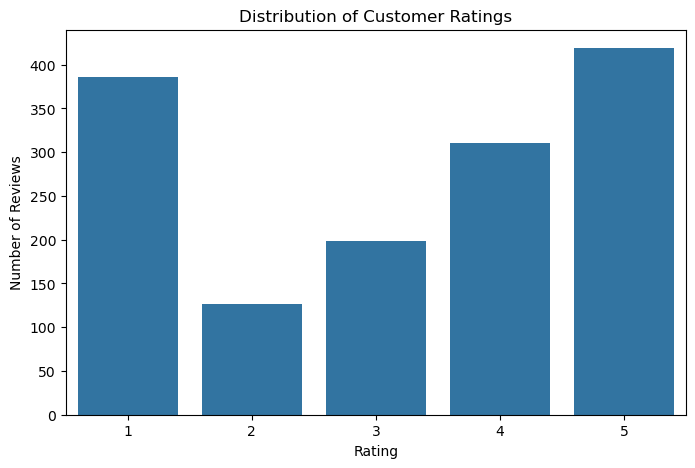

In [14]:
# Visualize rating distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="rating",
    order=sorted(df["rating"].unique())
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show() 

In [15]:
# Convert ratings into sentiment labels

def create_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"


df["sentiment"] = df["rating"].apply(create_sentiment)

df[["rating", "sentiment"]].head() 

,rating,sentiment
0,1,Negative
1,3,Neutral
2,4,Positive
3,1,Negative
4,1,Negative


In [16]:
# Check sentiment distribution

sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

print("\nSentiment Percentage:")
print(
    (sentiment_counts / len(df) * 100).round(2)
) 

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

Sentiment Percentage:
sentiment
Positive    50.62
Negative    35.56
Neutral     13.82
Name: count, dtype: float64


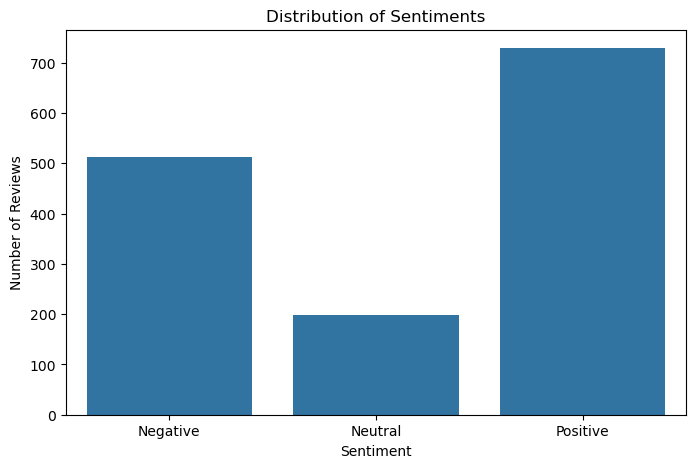

In [17]:
# Visualize sentiment distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sentiment",
    order=["Negative", "Neutral", "Positive"]
)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show() 

In [18]:
# Combine review title and review body

df["review_text"] = (
    df["title"].fillna("").astype(str)
    + " "
    + df["body"].fillna("").astype(str)
)

df[["title", "body", "review_text"]].head() 

,title,body,review_text
0,Horrible product,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...


In [19]:
# Create basic text-based features

df["character_count"] = df["review_text"].str.len()

df["word_count"] = (
    df["review_text"]
    .str.split()
    .str.len()
)

df["sentence_count"] = (
    df["review_text"]
    .str.count(r"[.!?]")
)

df[[
    "character_count",
    "word_count",
    "sentence_count"
]].describe() 

,character_count,word_count,sentence_count
count,1440.000000,1440.000000,1440.000000
mean,333.381944,58.257639,6.147917
std,229.116704,39.896874,6.408033
min,9.000000,2.000000,0.000000
25%,198.000000,34.000000,2.000000
50%,277.000000,49.000000,5.000000
75%,395.000000,70.000000,8.000000
max,2536.000000,391.000000,69.000000


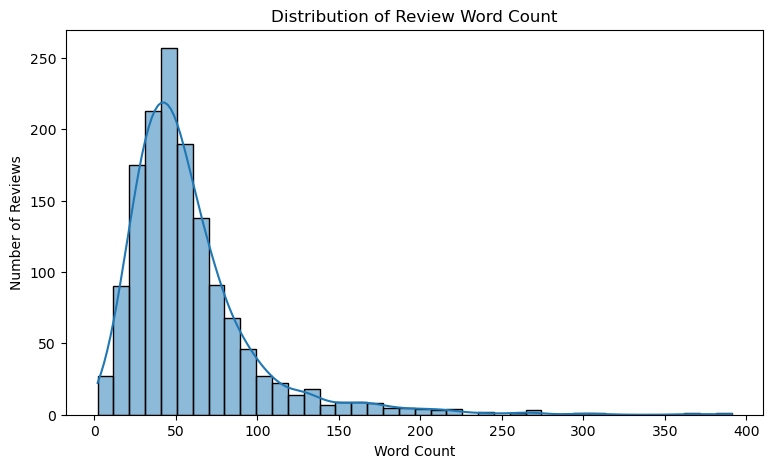

In [20]:
# Analyze the distribution of review word counts

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="word_count",
    bins=40,
    kde=True
)

plt.title("Distribution of Review Word Count")
plt.xlabel("Word Count")
plt.ylabel("Number of Reviews")
plt.show() 

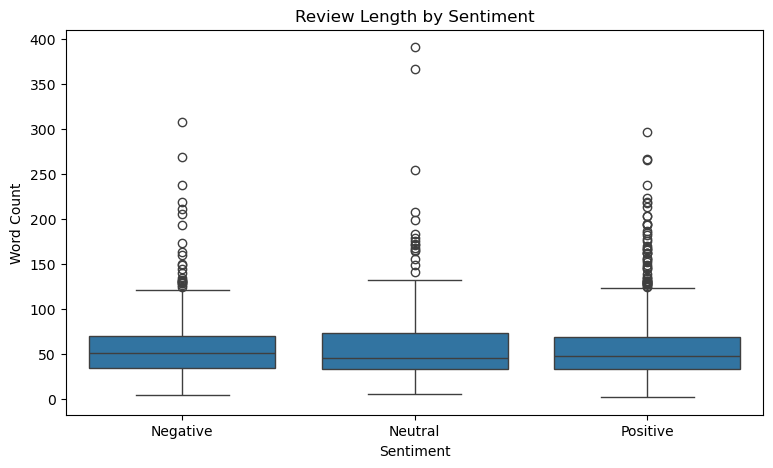

In [21]:
# Compare review length across sentiment categories

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="word_count",
    order=["Negative", "Neutral", "Positive"]
)

plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.show() 

In [22]:
# Calculate average review length for each sentiment

sentiment_length = (
    df.groupby("sentiment")[["word_count", "character_count"]]
    .mean()
    .round(2)
)

sentiment_length 

,word_count,character_count
sentiment,,
Negative,57.96,331.19
Neutral,61.86,352.92
Positive,57.48,329.59


In [23]:
# Define a text cleaning function

def clean_text(text):
    
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text 

In [24]:
# Apply text cleaning

df["clean_text"] = df["review_text"].apply(clean_text)

df[["review_text", "clean_text"]].head() 

,review_text,clean_text
0,Horrible product Very disappointed with the ov...,horrible product very disappointed with the ov...
1,Camera quality is not like 48 megapixel Camera...,camera quality is not like 48 megapixel camera...
2,"Overall Got the mobile on the launch date,Batt...",overall got the mobile on the launch datebatte...
3,A big no from me 1. It doesn't work with 5.0GH...,a big no from me 1 it doesnt work with 50ghz w...
4,Put your money somewhere else Not worth buying...,put your money somewhere else not worth buying...


In [25]:
# Prepare stopwords

stop_words = set(stopwords.words("english"))

# Keep important negation words for sentiment analysis
stop_words = stop_words - {"not", "no", "never"}

def tokenize_text(text):
    
    tokens = word_tokenize(text)
    
    tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]
    
    return tokens


df["tokens"] = df["clean_text"].apply(tokenize_text)

df[["clean_text", "tokens"]].head() 

,clean_text,tokens
0,horrible product very disappointed with the ov...,"[horrible, product, disappointed, overall, per..."
1,camera quality is not like 48 megapixel camera...,"[camera, quality, not, like, megapixel, camera..."
2,overall got the mobile on the launch datebatte...,"[overall, got, mobile, launch, datebattery, mu..."
3,a big no from me 1 it doesnt work with 50ghz w...,"[big, no, doesnt, work, wifi, frequency, old, ..."
4,put your money somewhere else not worth buying...,"[put, money, somewhere, else, not, worth, buyi..."


In [26]:
# Apply lemmatization

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    
    return [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]


df["lemmatized_tokens"] = (
    df["tokens"].apply(lemmatize_tokens)
) 

In [27]:
# Convert processed tokens back into text

df["final_text"] = (
    df["lemmatized_tokens"]
    .apply(lambda x: " ".join(x))
)

df[[
    "review_text",
    "clean_text",
    "final_text",
    "sentiment"
]].head() 

,review_text,clean_text,final_text,sentiment
0,Horrible product Very disappointed with the ov...,horrible product very disappointed with the ov...,horrible product disappointed overall performa...,Negative
1,Camera quality is not like 48 megapixel Camera...,camera quality is not like 48 megapixel camera...,camera quality not like megapixel camera quali...,Neutral
2,"Overall Got the mobile on the launch date,Batt...",overall got the mobile on the launch datebatte...,overall got mobile launch datebattery must app...,Positive
3,A big no from me 1. It doesn't work with 5.0GH...,a big no from me 1 it doesnt work with 50ghz w...,big no doesnt work wifi frequency old camera q...,Negative
4,Put your money somewhere else Not worth buying...,put your money somewhere else not worth buying...,put money somewhere else not worth buyingfault...,Negative


In [28]:
# Verify preprocessing results

print("Original Review:")
print(df["review_text"].iloc[0])

print("\nProcessed Review:")
print(df["final_text"].iloc[0]) 

Original Review:
Horrible product Very disappointed with the overall performance from Samsung

Processed Review:
horrible product disappointed overall performance samsung


In [29]:
# Find the most frequently occurring words

all_words = [
    word
    for tokens in df["lemmatized_tokens"]
    for word in tokens
]

word_frequency = Counter(all_words)

most_common_words = (
    pd.DataFrame(
        word_frequency.most_common(20),
        columns=["Word", "Frequency"]
    )
)

most_common_words 

,Word,Frequency
0,phone,1901
1,not,1405
2,good,1343
3,camera,964
4,battery,794
5,samsung,744
6,quality,692
7,mobile,606
8,price,440
9,product,436


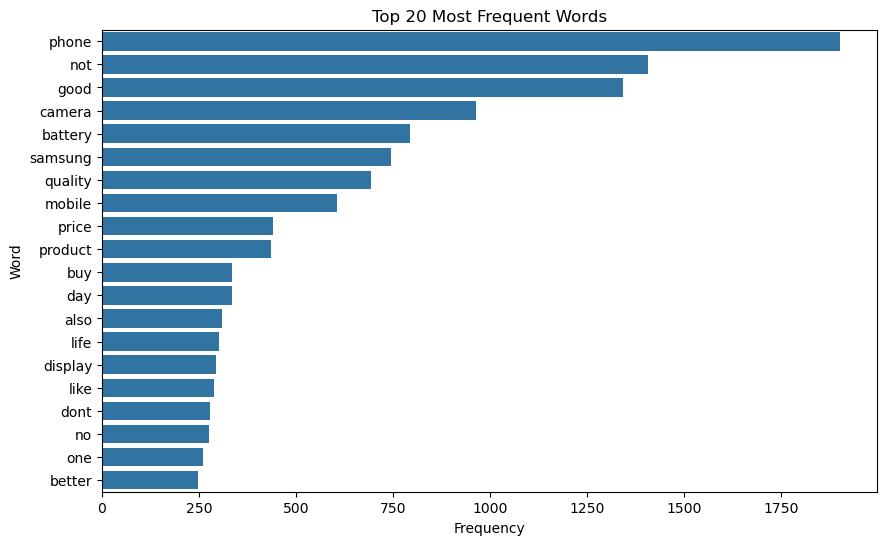

In [30]:
# Visualize the most frequent words

plt.figure(figsize=(10, 6))

sns.barplot(
    data=most_common_words,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show() 

In [31]:
# Function to find common words for each sentiment

def get_common_words(sentiment, n=15):
    
    words = [
        word
        for tokens in df.loc[
            df["sentiment"] == sentiment,
            "lemmatized_tokens"
        ]
        for word in tokens
    ]
    
    return Counter(words).most_common(n)


negative_words = get_common_words("Negative")
neutral_words = get_common_words("Neutral")
positive_words = get_common_words("Positive")

print("Negative:")
print(negative_words)

print("\nNeutral:")
print(neutral_words)

print("\nPositive:")
print(positive_words) 

Negative:
[('phone', 666), ('not', 640), ('samsung', 355), ('mobile', 291), ('camera', 263), ('quality', 243), ('product', 228), ('buy', 212), ('dont', 182), ('worst', 182), ('good', 174), ('amazon', 169), ('battery', 157), ('no', 122), ('bad', 114)]

Neutral:
[('not', 302), ('phone', 279), ('good', 189), ('camera', 167), ('quality', 118), ('battery', 101), ('mobile', 95), ('samsung', 90), ('average', 70), ('price', 56), ('better', 46), ('heavy', 46), ('also', 44), ('no', 42), ('time', 41)]

Positive:
[('good', 980), ('phone', 956), ('battery', 536), ('camera', 534), ('not', 463), ('quality', 331), ('price', 323), ('samsung', 299), ('mobile', 220), ('life', 216), ('budget', 206), ('best', 204), ('great', 192), ('day', 190), ('product', 181)]


In [32]:
# Final data quality check before modelling

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows using the original dataset columns
duplicate_count = df[
    ["title", "rating", "body"]
].duplicated().sum()

print("\nDuplicate Rows:", duplicate_count)

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())

print("\nEmpty Processed Reviews:")
print(
    (df["final_text"].fillna("").str.strip() == "").sum()
)

Dataset Shape: (1440, 12)

Missing Values:
title                0
rating               0
body                 0
sentiment            0
review_text          0
character_count      0
word_count           0
sentence_count       0
clean_text           0
tokens               0
lemmatized_tokens    0
final_text           0
dtype: int64

Duplicate Rows: 0

Sentiment Distribution:
sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

Empty Processed Reviews:
0


In [33]:
# Prepare text features and target variable

X = df["final_text"]
y = df["sentiment"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape) 

Feature Shape: (1440,)
Target Shape: (1440,)


In [34]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test)) 

Training Samples: 1152
Testing Samples: 288


In [35]:
# Convert text into TF-IDF features

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape) 

Training TF-IDF Shape: (1152, 5334)
Testing TF-IDF Shape: (288, 5334)


### Model Building

In [36]:
# Import classification models and evaluation metrics

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [37]:
# Define six classification models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Multinomial Naive Bayes": MultinomialNB(),

    "Bernoulli Naive Bayes": BernoulliNB(),

    "Linear SVM": LinearSVC(
        C=1.0,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    )
}

print("Number of models:", len(models))
print("\nModels:")
for model_name in models:
    print("-", model_name)

Number of models: 6

Models:
- Logistic Regression
- Multinomial Naive Bayes
- Bernoulli Naive Bayes
- Linear SVM
- Random Forest
- K-Nearest Neighbors


In [38]:
# Train all six models

predictions = {}

for model_name, model in models.items():

    print(f"Training {model_name}...")

    model.fit(
        X_train_tfidf,
        y_train
    )

    predictions[model_name] = model.predict(
        X_test_tfidf
    )

print("\nAll six models trained successfully.")

Training Logistic Regression...
Training Multinomial Naive Bayes...
Training Bernoulli Naive Bayes...
Training Linear SVM...
Training Random Forest...
Training K-Nearest Neighbors...

All six models trained successfully.


In [39]:
# Evaluate all six models

results = []

for model_name, model_predictions in predictions.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            model_predictions
        ),
        "Precision": precision_score(
            y_test,
            model_predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            model_predictions,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            model_predictions,
            average="weighted",
            zero_division=0
        )
    })

model_results = pd.DataFrame(results)

model_results = model_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

model_results.round(4) 

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.7882,0.7539,0.7882,0.7599
1,Logistic Regression,0.7847,0.7478,0.7847,0.7317
2,Bernoulli Naive Bayes,0.7639,0.7332,0.7639,0.7228
3,K-Nearest Neighbors,0.7431,0.6995,0.7431,0.7152
4,Random Forest,0.7569,0.6515,0.7569,0.6998
5,Multinomial Naive Bayes,0.7465,0.6571,0.7465,0.6882


In [40]:
# Compare accuracy of all six models

accuracy_results = model_results[
    ["Model", "Accuracy"]
].copy()

accuracy_results["Accuracy"] = (
    accuracy_results["Accuracy"] * 100
).round(2)

accuracy_results 

,Model,Accuracy
0,Linear SVM,78.82
1,Logistic Regression,78.47
2,Bernoulli Naive Bayes,76.39
3,K-Nearest Neighbors,74.31
4,Random Forest,75.69
5,Multinomial Naive Bayes,74.65


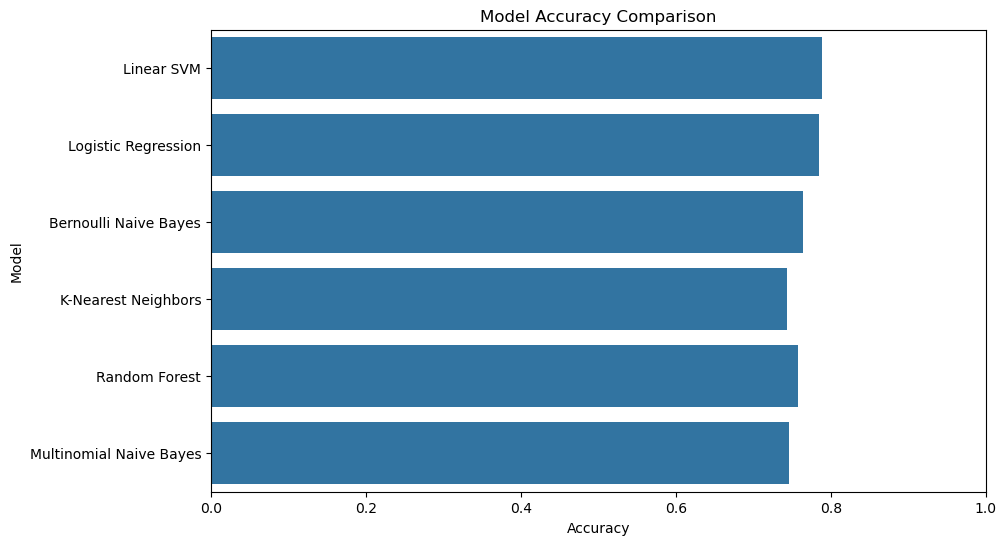

In [41]:
# Visualize model accuracy

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show() 

In [42]:
# Display complete performance comparison

display(
    model_results.round(4)
) 


,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.7882,0.7539,0.7882,0.7599
1,Logistic Regression,0.7847,0.7478,0.7847,0.7317
2,Bernoulli Naive Bayes,0.7639,0.7332,0.7639,0.7228
3,K-Nearest Neighbors,0.7431,0.6995,0.7431,0.7152
4,Random Forest,0.7569,0.6515,0.7569,0.6998
5,Multinomial Naive Bayes,0.7465,0.6571,0.7465,0.6882


In [43]:
# Select the best model based on weighted F1 score

best_model_name = model_results.loc[
    0,
    "Model"
]

best_model = models[
    best_model_name
]

best_predictions = predictions[
    best_model_name
]

best_accuracy = accuracy_score(
    y_test,
    best_predictions
)

print("Best Model:", best_model_name)

print(
    f"Testing Accuracy: {best_accuracy * 100:.2f}%"
)

Best Model: Linear SVM
Testing Accuracy: 78.82%


In [44]:
# Generate classification report for the best model

print(
    classification_report(
        y_test,
        best_predictions,
        digits=4,
        zero_division=0
    )
) 

              precision    recall  f1-score   support

    Negative     0.7838    0.8529    0.8169       102
     Neutral     0.4286    0.1500    0.2222        40
    Positive     0.8221    0.9178    0.8673       146

    accuracy                         0.7882       288
   macro avg     0.6781    0.6402    0.6355       288
weighted avg     0.7539    0.7882    0.7599       288



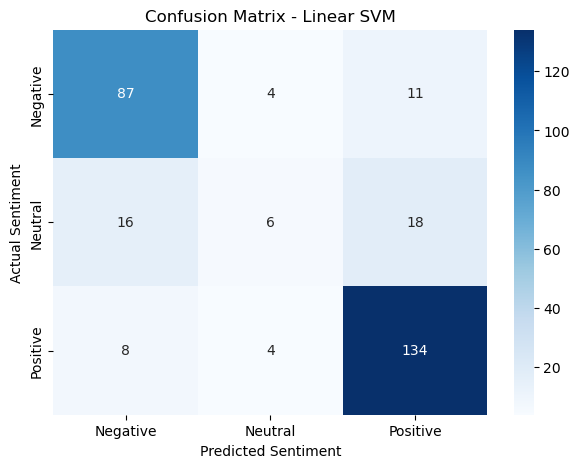

In [45]:
# Generate confusion matrix for the best model

class_labels = [
    "Negative",
    "Neutral",
    "Positive"
]

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=class_labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show() 

In [46]:
# Check whether the final model is overfitting

train_predictions = best_model.predict(
    X_train_tfidf
)

test_predictions = best_model.predict(
    X_test_tfidf
)

train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

accuracy_difference = (
    train_accuracy - test_accuracy
)

print(
    f"Training Accuracy: {train_accuracy * 100:.2f}%"
)

print(
    f"Testing Accuracy: {test_accuracy * 100:.2f}%"
)

print(
    f"Accuracy Difference: {accuracy_difference * 100:.2f}%"
) 

Training Accuracy: 100.00%
Testing Accuracy: 78.82%
Accuracy Difference: 21.18%


In [47]:
# Calculate final performance metrics

final_accuracy = accuracy_score(
    y_test,
    best_predictions
)

final_precision = precision_score(
    y_test,
    best_predictions,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    best_predictions,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    best_predictions,
    average="weighted",
    zero_division=0
)

print("Final Model Performance")
print()
print("Model:", best_model_name)
print(f"Accuracy: {final_accuracy * 100:.2f}%")
print(f"Precision: {final_precision * 100:.2f}%")
print(f"Recall: {final_recall * 100:.2f}%")
print(f"F1 Score: {final_f1 * 100:.2f}%") 

Final Model Performance

Model: Linear SVM
Accuracy: 78.82%
Precision: 75.39%
Recall: 78.82%
F1 Score: 75.99%


In [48]:
# Create a concise final summary

final_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        best_model_name,
        f"{final_accuracy * 100:.2f}%",
        f"{final_precision * 100:.2f}%",
        f"{final_recall * 100:.2f}%",
        f"{final_f1 * 100:.2f}%"
    ]
})

final_summary 

,Metric,Value
0,Model,Linear SVM
1,Accuracy,78.82%
2,Precision,75.39%
3,Recall,78.82%
4,F1 Score,75.99%


In [49]:
# Display all models ranked by F1 score

final_comparison = model_results.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:
    final_comparison[column] = (
        final_comparison[column] * 100
    ).round(2)

final_comparison 

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,78.82,75.39,78.82,75.99
1,Logistic Regression,78.47,74.78,78.47,73.17
2,Bernoulli Naive Bayes,76.39,73.32,76.39,72.28
3,K-Nearest Neighbors,74.31,69.95,74.31,71.52
4,Random Forest,75.69,65.15,75.69,69.98
5,Multinomial Naive Bayes,74.65,65.71,74.65,68.82


In [50]:
# Import GridSearchCV for hyperparameter tuning

from sklearn.model_selection import GridSearchCV 

In [51]:
# Define parameters to test for Linear SVM

param_grid = {
    "C": [0.1, 0.5, 1, 2, 5]
} 

In [52]:
# Tune Linear SVM using cross-validation

svm_grid = GridSearchCV(
    estimator=LinearSVC(
        random_state=42
    ),
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

svm_grid.fit(
    X_train_tfidf,
    y_train
)

print("Best Parameters:")
print(svm_grid.best_params_)

print(
    "\nBest Cross-Validation F1 Score:",
    round(svm_grid.best_score_, 4)
) 

Best Parameters:
{'C': 2}

Best Cross-Validation F1 Score: 0.7743


In [53]:
# Get the best tuned Linear SVM model

final_svm_model = svm_grid.best_estimator_

final_svm_predictions = final_svm_model.predict(
    X_test_tfidf
) 

In [54]:
# Calculate performance of the tuned Linear SVM

tuned_accuracy = accuracy_score(
    y_test,
    final_svm_predictions
)

tuned_precision = precision_score(
    y_test,
    final_svm_predictions,
    average="weighted",
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    final_svm_predictions,
    average="weighted",
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    final_svm_predictions,
    average="weighted",
    zero_division=0
)

print("Tuned Linear SVM Performance")
print()
print(f"Accuracy: {tuned_accuracy * 100:.2f}%")
print(f"Precision: {tuned_precision * 100:.2f}%")
print(f"Recall: {tuned_recall * 100:.2f}%")
print(f"F1 Score: {tuned_f1 * 100:.2f}%") 

Tuned Linear SVM Performance

Accuracy: 78.47%
Precision: 75.65%
Recall: 78.47%
F1 Score: 76.28%


In [55]:
# Compare baseline and tuned Linear SVM

comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear SVM",
        "Tuned Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            predictions["Linear SVM"]
        ),
        tuned_accuracy
    ],
    "F1 Score": [
        f1_score(
            y_test,
            predictions["Linear SVM"],
            average="weighted",
            zero_division=0
        ),
        tuned_f1
    ]
})

comparison_percent = comparison.copy()

comparison_percent["Accuracy"] = (
    comparison_percent["Accuracy"] * 100
).round(2)

comparison_percent["F1 Score"] = (
    comparison_percent["F1 Score"] * 100
).round(2)

comparison_percent 

,Model,Accuracy,F1 Score
0,Baseline Linear SVM,78.82,75.99
1,Tuned Linear SVM,78.47,76.28


In [56]:
# Generate the final classification report

print(
    classification_report(
        y_test,
        final_svm_predictions,
        digits=4,
        zero_division=0
    )
) 

              precision    recall  f1-score   support

    Negative     0.7778    0.8235    0.8000       102
     Neutral     0.4444    0.2000    0.2759        40
    Positive     0.8272    0.9178    0.8701       146

    accuracy                         0.7847       288
   macro avg     0.6831    0.6471    0.6487       288
weighted avg     0.7565    0.7847    0.7628       288



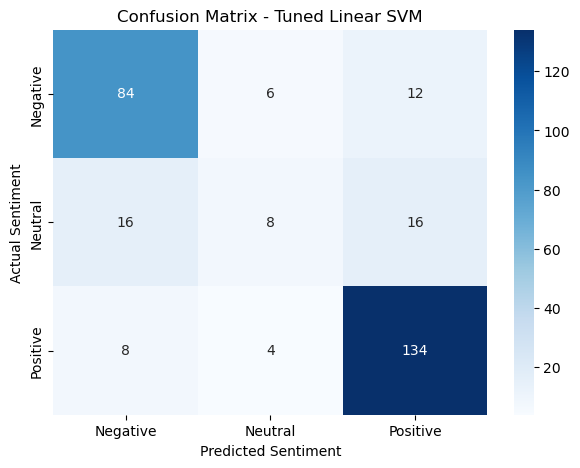

In [57]:
# Create the confusion matrix for the final model

class_labels = [
    "Negative",
    "Neutral",
    "Positive"
]

final_cm = confusion_matrix(
    y_test,
    final_svm_predictions,
    labels=class_labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix - Tuned Linear SVM")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show() 

In [58]:
# Check training and testing performance of the final model

final_train_predictions = final_svm_model.predict(
    X_train_tfidf
)

final_train_accuracy = accuracy_score(
    y_train,
    final_train_predictions
)

final_test_accuracy = accuracy_score(
    y_test,
    final_svm_predictions
)

final_accuracy_difference = (
    final_train_accuracy - final_test_accuracy
)

print(
    f"Training Accuracy: {final_train_accuracy * 100:.2f}%"
)

print(
    f"Testing Accuracy: {final_test_accuracy * 100:.2f}%"
)

print(
    f"Accuracy Difference: {final_accuracy_difference * 100:.2f}%"
) 

Training Accuracy: 100.00%
Testing Accuracy: 78.47%
Accuracy Difference: 21.53%


In [59]:
# Create the final model performance summary

final_model_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        "Tuned Linear SVM",
        f"{tuned_accuracy * 100:.2f}%",
        f"{tuned_precision * 100:.2f}%",
        f"{tuned_recall * 100:.2f}%",
        f"{tuned_f1 * 100:.2f}%"
    ]
})

final_model_summary 

,Metric,Value
0,Model,Tuned Linear SVM
1,Accuracy,78.47%
2,Precision,75.65%
3,Recall,78.47%
4,F1 Score,76.28%


In [60]:
# Check training and testing accuracy of the baseline Linear SVM

baseline_svm_model = models["Linear SVM"]

baseline_train_predictions = baseline_svm_model.predict(
    X_train_tfidf
)

baseline_test_predictions = baseline_svm_model.predict(
    X_test_tfidf
)

baseline_train_accuracy = accuracy_score(
    y_train,
    baseline_train_predictions
)

baseline_test_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions
)

baseline_accuracy_difference = (
    baseline_train_accuracy
    - baseline_test_accuracy
)

print(
    f"Training Accuracy: {baseline_train_accuracy * 100:.2f}%"
)

print(
    f"Testing Accuracy: {baseline_test_accuracy * 100:.2f}%"
)

print(
    f"Accuracy Difference: {baseline_accuracy_difference * 100:.2f}%"
) 

Training Accuracy: 100.00%
Testing Accuracy: 78.82%
Accuracy Difference: 21.18%


In [61]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

# Define a stronger regularization search range

improved_param_grid = {
    "C": [
        0.001,
        0.005,
        0.01,
        0.05,
        0.1,
        0.5,
        1.0
    ]
}

# Perform cross-validation

improved_svm_grid = GridSearchCV(
    estimator=LinearSVC(
        random_state=42,
        max_iter=5000
    ),
    param_grid=improved_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

improved_svm_grid.fit(
    X_train_tfidf,
    y_train
)

print("Best Parameters:")
print(improved_svm_grid.best_params_)

print(
    "\nBest Cross-Validation F1 Score:",
    f"{improved_svm_grid.best_score_:.4f}"
) 

Best Parameters:
{'C': 1.0}

Best Cross-Validation F1 Score: 0.7717


In [62]:
# Get the improved Linear SVM model

improved_svm_model = improved_svm_grid.best_estimator_

# Generate predictions

improved_train_predictions = improved_svm_model.predict(
    X_train_tfidf
)

improved_test_predictions = improved_svm_model.predict(
    X_test_tfidf
)

# Calculate metrics

improved_train_accuracy = accuracy_score(
    y_train,
    improved_train_predictions
)

improved_test_accuracy = accuracy_score(
    y_test,
    improved_test_predictions
)

improved_precision = precision_score(
    y_test,
    improved_test_predictions,
    average="weighted",
    zero_division=0
)

improved_recall = recall_score(
    y_test,
    improved_test_predictions,
    average="weighted",
    zero_division=0
)

improved_f1 = f1_score(
    y_test,
    improved_test_predictions,
    average="weighted",
    zero_division=0
)

improved_gap = (
    improved_train_accuracy
    - improved_test_accuracy
)

print(
    f"Training Accuracy: {improved_train_accuracy * 100:.2f}%"
)

print(
    f"Testing Accuracy: {improved_test_accuracy * 100:.2f}%"
)

print(
    f"Precision: {improved_precision * 100:.2f}%"
)

print(
    f"Recall: {improved_recall * 100:.2f}%"
)

print(
    f"F1 Score: {improved_f1 * 100:.2f}%"
)

print(
    f"Accuracy Difference: {improved_gap * 100:.2f}%"
) 

Training Accuracy: 100.00%
Testing Accuracy: 78.82%
Precision: 75.39%
Recall: 78.82%
F1 Score: 75.99%
Accuracy Difference: 21.18%


In [63]:
# Compare all Linear SVM versions

svm_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear SVM",
        "Initial Tuned Linear SVM",
        "Improved Regularized Linear SVM"
    ],
    
    "Training Accuracy": [
        baseline_train_accuracy,
        final_train_accuracy,
        improved_train_accuracy
    ],
    
    "Testing Accuracy": [
        baseline_test_accuracy,
        tuned_accuracy,
        improved_test_accuracy
    ],
    
    "F1 Score": [
        f1_score(
            y_test,
            predictions["Linear SVM"],
            average="weighted",
            zero_division=0
        ),
        tuned_f1,
        improved_f1
    ],
    
    "Generalization Gap": [
        baseline_accuracy_difference,
        final_accuracy_difference,
        improved_gap
    ]
})

svm_comparison_percent = svm_comparison.copy()

for column in [
    "Training Accuracy",
    "Testing Accuracy",
    "F1 Score",
    "Generalization Gap"
]:
    
    svm_comparison_percent[column] = (
        svm_comparison_percent[column] * 100
    ).round(2)

svm_comparison_percent 

,Model,Training Accuracy,Testing Accuracy,F1 Score,Generalization Gap
0,Baseline Linear SVM,100.0,78.82,75.99,21.18
1,Initial Tuned Linear SVM,100.0,78.47,76.28,21.53
2,Improved Regularized Linear SVM,100.0,78.82,75.99,21.18


In [64]:
# Import Pipeline and GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC 

In [65]:
# Create the NLP classification pipeline

svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            sublinear_tf=True
        )
    ),
    
    (
        "svm",
        LinearSVC(
            random_state=42,
            max_iter=5000
        )
    )
]) 

In [66]:
# Define TF-IDF and Linear SVM parameters

pipeline_param_grid = {
    
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2),
        (1, 3)
    ],
    
    "tfidf__min_df": [
        1,
        2,
        3
    ],
    
    "tfidf__max_df": [
        0.90,
        0.95,
        1.0
    ],
    
    "tfidf__max_features": [
        10000,
        20000
    ],
    
    "svm__C": [
        0.01,
        0.05,
        0.1,
        0.5,
        1.0
    ]
} 

In [67]:
# Perform TF-IDF and Linear SVM hyperparameter tuning

pipeline_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=pipeline_param_grid,
    scoring="f1_weighted",
    cv=5, 
    n_jobs=-1,
    verbose=1
)

pipeline_grid.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(pipeline_grid.best_params_)

print(
    "\nBest Cross-Validation F1 Score:",
    f"{pipeline_grid.best_score_:.4f}"
) 

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best Parameters:
{'svm__C': 1.0, 'tfidf__max_df': 0.9, 'tfidf__max_features': 10000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}

Best Cross-Validation F1 Score: 0.7800


In [68]:
# Get the best tuned pipeline

best_pipeline = pipeline_grid.best_estimator_

# Generate predictions on unseen test data

pipeline_predictions = best_pipeline.predict(
    X_test
)

# Calculate evaluation metrics

pipeline_accuracy = accuracy_score(
    y_test,
    pipeline_predictions
)

pipeline_precision = precision_score(
    y_test,
    pipeline_predictions,
    average="weighted",
    zero_division=0
)

pipeline_recall = recall_score(
    y_test,
    pipeline_predictions,
    average="weighted",
    zero_division=0
)

pipeline_f1 = f1_score(
    y_test,
    pipeline_predictions,
    average="weighted",
    zero_division=0
)

print("Best TF-IDF + Linear SVM Pipeline")
print()
print(f"Accuracy: {pipeline_accuracy * 100:.2f}%")
print(f"Precision: {pipeline_precision * 100:.2f}%")
print(f"Recall: {pipeline_recall * 100:.2f}%")
print(f"F1 Score: {pipeline_f1 * 100:.2f}%") 

Best TF-IDF + Linear SVM Pipeline

Accuracy: 78.82%
Precision: 75.39%
Recall: 78.82%
F1 Score: 75.99%


In [69]:
# Compare the original Linear SVM with the tuned pipeline

final_pipeline_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear SVM",
        "Tuned TF-IDF + Linear SVM Pipeline"
    ],
    
    "Accuracy": [
        baseline_test_accuracy,
        pipeline_accuracy
    ],
    
    "F1 Score": [
        f1_score(
            y_test,
            predictions["Linear SVM"],
            average="weighted",
            zero_division=0
        ),
        pipeline_f1
    ]
})

comparison_display = final_pipeline_comparison.copy()

comparison_display["Accuracy"] = (
    comparison_display["Accuracy"] * 100
).round(2)

comparison_display["F1 Score"] = (
    comparison_display["F1 Score"] * 100
).round(2)

comparison_display 

,Model,Accuracy,F1 Score
0,Baseline Linear SVM,78.82,75.99
1,Tuned TF-IDF + Linear SVM Pipeline,78.82,75.99


In [70]:
# Select the final model

final_model = models["Linear SVM"]

print("Final Model:", "Linear SVM") 

Final Model: Linear SVM


In [71]:
# Import joblib for saving the trained model and vectorizer

import joblib

In [72]:
# Save the trained Linear SVM model

joblib.dump(
    final_model,
    "linear_svm_sentiment_model.pkl"
)

print("Linear SVM model saved successfully.") 

Linear SVM model saved successfully.


In [73]:
print(type(tfidf)) 

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [74]:
# Save the fitted TF-IDF vectorizer

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("TF-IDF vectorizer saved successfully.") 

TF-IDF vectorizer saved successfully.


In [75]:
import os

print("Model exists:",
      os.path.exists("linear_svm_sentiment_model.pkl"))

print("Vectorizer exists:",
      os.path.exists("tfidf_vectorizer.pkl")) 

Model exists: True
Vectorizer exists: True


In [76]:
# Load the saved model and vectorizer

loaded_model = joblib.load(
    "linear_svm_sentiment_model.pkl"
)

loaded_vectorizer = joblib.load(
    "tfidf_vectorizer.pkl"
)

print("Model loaded successfully.")
print("Vectorizer loaded successfully.") 

Model loaded successfully.
Vectorizer loaded successfully.


In [77]:
# Test the saved model with sample text

sample_text = [
    "This product is excellent and I really enjoyed using it."
]

sample_vector = loaded_vectorizer.transform(
    sample_text
)

prediction = loaded_model.predict(
    sample_vector
)

print("Text:", sample_text[0])
print("Predicted Sentiment:", prediction[0]) 

Text: This product is excellent and I really enjoyed using it.
Predicted Sentiment: Positive
